In [1]:
# standard library
import os
import re
from datetime import datetime
from pathlib import Path

# arrays / tables / plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import seaborn as sns
import xarray as xr

# geospatial
import geopandas as gpd
import folium
import contextily as ctx
import rasterio
from rasterio.plot import show
from rasterio.features import rasterize

# shapely geometry / operations
from shapely.geometry import (Point, LineString, MultiPoint, GeometryCollection, mapping,)
import shapely.ops as ops

# stats / interpolation / geostats
import scipy.interpolate
import scipy.stats
import skgstat as skg
import tqdm

# spatial stats
import pysal
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot

# machine learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# cartographic helpers
from matplotlib_scalebar.scalebar import ScaleBar

/opt/conda/lib/python3.11/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
# Calls the combined dataframe and sends it to a new xarray
final_df = pd.read_csv("/home/jovyan/Society_of_Bouy_Cowboys/Data/Organized_Data/final_df.csv")
#final_df
final_ds = xr.open_dataset("/home/jovyan/Society_of_Bouy_Cowboys/Data/Organized_Data/final_ds.nc")
#final_ds

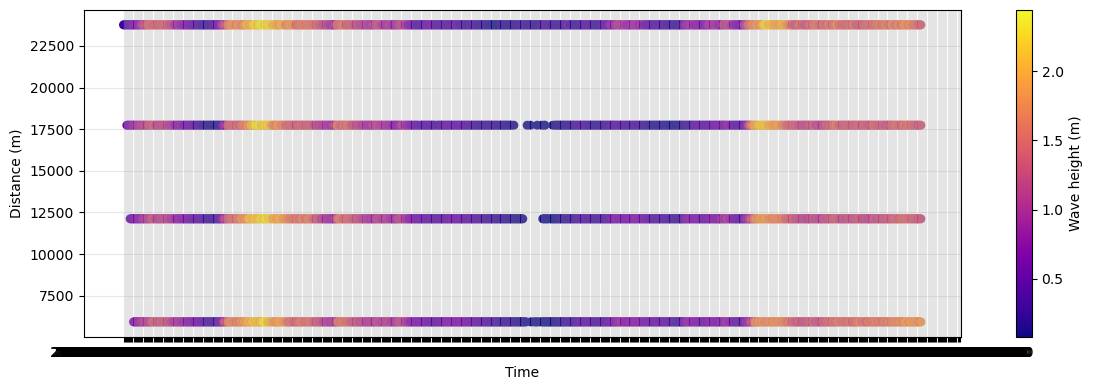

In [3]:
# Plot of wave hights over time (full time series)
S1P1= final_df[final_df['source']=='S1P1']
S1P2= final_df[final_df['source']=='S1P2']
S1P3= final_df[final_df['source']=='S1P3']
S1A1= final_df[final_df['source']=='S1A1']

f, ax = plt.subplots(1,1, figsize=(12,4))
sc_P1=ax.scatter(S1P1['time'], S1P1['moor_dist_m'], c=S1P1['wave_height_m'], cmap='plasma', s=30)
plt.colorbar(sc_P1, ax=ax, label="Wave height (m)")

sc_P2=ax.scatter(S1P2['time'], S1P2['moor_dist_m'], c=S1P2['wave_height_m'], cmap='plasma', s=30)
sc_P3=ax.scatter(S1P3['time'], S1P3['moor_dist_m'], c=S1P3['wave_height_m'], cmap='plasma', s=30)
sc_A1=ax.scatter(S1A1['time'], S1A1['moor_dist_m'], c=S1A1['wave_height_m'], cmap='plasma', s=30)

ax.set_xlabel("Time")
ax.set_ylabel("Distance (m)")

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# Examines ice edge column
#final_df['ice_edge_dist_m']

In [5]:
# Fills missing ice-edge distances via linear interpolation in time
final_ds["ice_edge_dist_m"] = final_ds["ice_edge_dist_m"].interpolate_na(dim="time", method="linear")

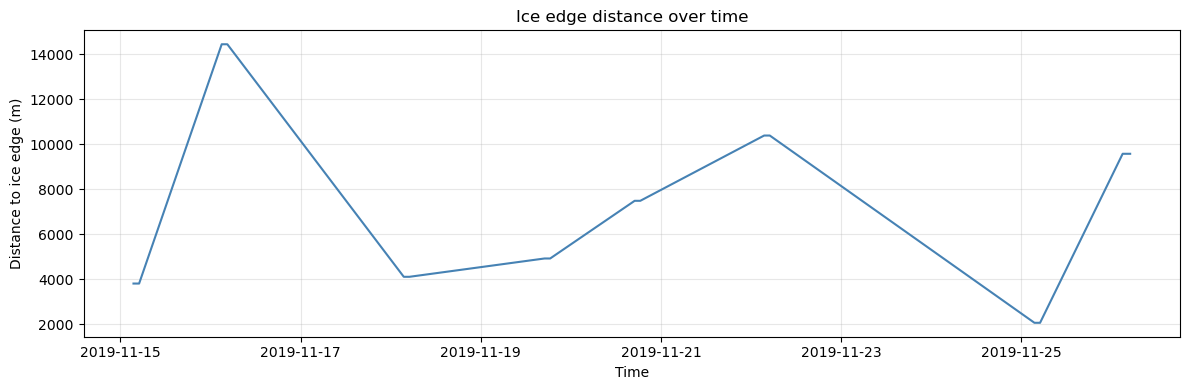

In [6]:
# Plot of ice edge x position over time
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(final_ds["time"], final_ds["ice_edge_dist_m"], color="steelblue", linewidth=1.5)

ax.set_xlabel("Time")
ax.set_ylabel("Distance to ice edge (m)")
ax.set_title("Ice edge distance over time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

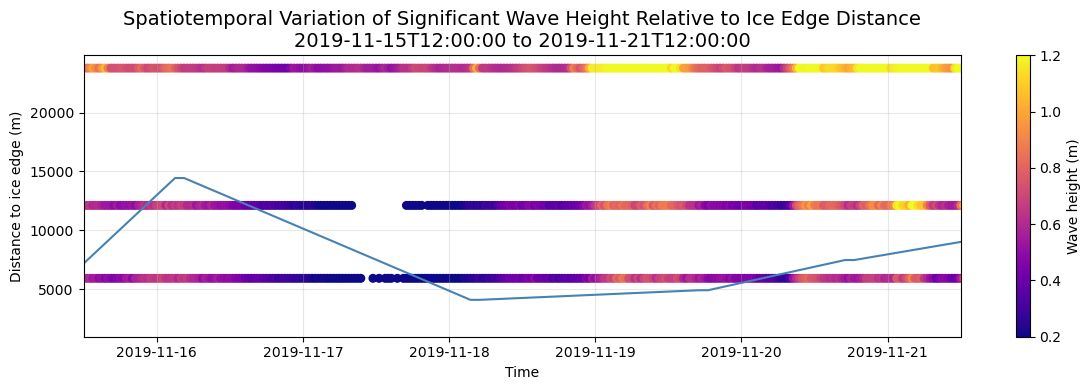

In [7]:
# Adjustable time scale to zoom in on most clearly descriptive section
TIME_START = "2019-11-15T12:00:00"
TIME_END   = "2019-11-21T12:00:00"
ds_slice = final_ds.sel(time=slice(TIME_START, TIME_END))
times = pd.to_datetime(final_ds["time"].values)
dist  = final_ds["ice_edge_dist_m"].values

# colormap constraints
vmin=0.2
vmax=1.2

# Combined plot of wave heights at mooring x positons and ice edge dx/dt
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(final_ds["time"], final_ds["ice_edge_dist_m"], color="steelblue", linewidth=1.5)
sc_P1 = ax.scatter(S1P1["time"], S1P1["moor_dist_m"], c=S1P1["wave_height_m"], cmap="plasma", vmin=vmin, vmax=vmax,s=30)
sc_P2 = ax.scatter(S1P2["time"], S1P2["moor_dist_m"], c=S1P2["wave_height_m"], cmap="plasma", vmin=vmin, vmax=vmax,s=30)
#sc_P3 = ax.scatter(S1P3["time"], S1P3["moor_dist_m"], c=S1P3["wave_height_m"], cmap="plasma", vmin=vmin, vmax=vmax,s=30) #commented out because data seems to be corrupted and needs further examonation before use
sc_A1 = ax.scatter(S1A1["time"], S1A1["moor_dist_m"], c=S1A1["wave_height_m"], cmap="plasma", vmin=vmin, vmax=vmax,s=30)

plt.colorbar(sc_P1, ax=ax, label="Wave height (m)")
ax.set_xlim(pd.Timestamp(TIME_START), pd.Timestamp(TIME_END))
ax.set_xlabel("Time")
ax.set_ylabel("Distance to ice edge (m)")
ax.set_title(f"Spatiotemporal Variation of Significant Wave Height Relative to Ice Edge Distance\n{TIME_START} to {TIME_END}",fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout();

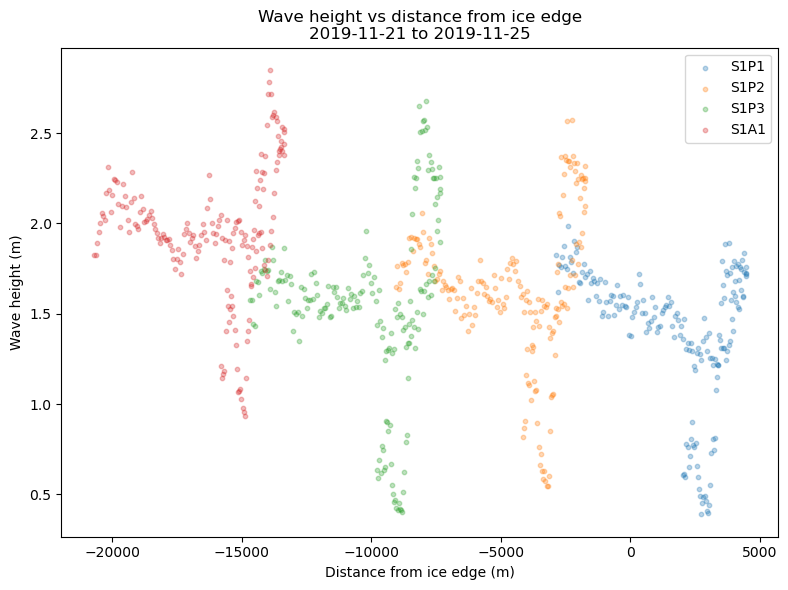

In [8]:
# Adjustable time scale to zoom in on most clearly descriptive section
TIME_START = "2019-11-21"
TIME_END   = "2019-11-25"
ds_slice = final_ds.sel(time=slice(TIME_START, TIME_END))

# Plot of significant wave height vs distance from ice edge
fig, ax = plt.subplots(figsize=(8, 6))

# Creates seperated point clouds - 1 for each mooring site
for source in ds_slice.source.values:
    wave = ds_slice["wave_height_m"].sel(source=source).values
    dist = ds_slice["dist_from_ice"].sel(source=source).values
    ax.scatter(dist, wave, label = source, alpha = 0.3, s = 10)

ax.set_xlabel("Distance from ice edge (m)")
ax.set_ylabel("Wave height (m)")
ax.set_title(f"Wave height vs distance from ice edge\n{TIME_START} to {TIME_END}")
ax.legend()
plt.tight_layout();

H0    = 1.4495 m
alpha = 0.000015 m⁻¹
decay length = 64.71 km


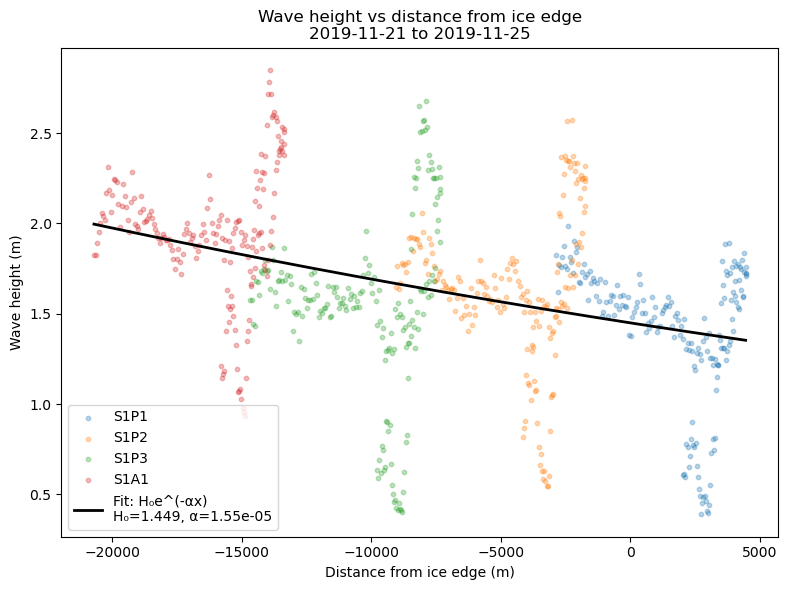

In [10]:
from scipy.optimize import curve_fit

# Adjustable Time Scale
TIME_START = "2019-11-21"
TIME_END   = "2019-11-25"

ds_slice = final_ds.sel(time=slice(TIME_START, TIME_END))

# Seperates wave and distance data 
all_dist = []
all_wave = []

for source in ds_slice.source.values:
    wave = ds_slice["wave_height_m"].sel(source=source).values
    dist = ds_slice["dist_from_ice"].sel(source=source).values
    
    # Removes NaNs
    mask = np.isfinite(wave) & np.isfinite(dist)
    all_dist.extend(dist[mask])
    all_wave.extend(wave[mask])

all_dist = np.array(all_dist)
all_wave = np.array(all_wave)

# Creates line of best fit using wave attenuation formula 
def exponential_decay(x, H0, alpha):
    return H0 * np.exp(-alpha * x)

popt, pcov = curve_fit( exponential_decay, all_dist, all_wave,
    p0     = [all_wave.max(), 1e-7],   # initial guess 
                      )

H0, alpha = popt
print(f"H0    = {H0:.4f} m")
print(f"alpha = {alpha:.6f} m⁻¹")
print(f"decay length = {1/alpha/1000:.2f} km")

# Creates plot
fig, ax = plt.subplots(figsize=(8, 6))

for source in ds_slice.source.values:
    wave = ds_slice["wave_height_m"].sel(source=source).values
    dist = ds_slice["dist_from_ice"].sel(source=source).values
    mask = np.isfinite(wave) & np.isfinite(dist)
    ax.scatter(dist[mask], wave[mask], label=source, alpha=0.3, s=10)

# Fits calculated line
x_fit = np.linspace(all_dist.min(), all_dist.max(), 300)
y_fit = exponential_decay(x_fit, H0, alpha)
ax.plot(x_fit, y_fit, color="black", linewidth=2,
        label=f"Fit: H₀e^(-αx)\nH₀={H0:.3f}, α={alpha:.2e}")

ax.set_xlabel("Distance from ice edge (m)")
ax.set_ylabel("Wave height (m)")
ax.set_title(f"Wave height vs distance from ice edge\n{TIME_START} to {TIME_END}")
ax.legend()
plt.tight_layout()
plt.show()